In [1]:
import io
import os
import boto3
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
from pathlib import Path
from dotenv import load_dotenv

load_dotenv(Path("../.env"))

s3 = boto3.client(
    "s3",
    endpoint_url=os.getenv("AISTOR_ENDPOINT"),
    aws_access_key_id=os.getenv("AISTOR_ACCESS_KEY"),
    aws_secret_access_key=os.getenv("AISTOR_SECRET_KEY")
)

In [2]:
classes = [
    "Black Sea Sprat",
    "Gilt-Head Bream",
    "Hourse Mackerel",
    "Red Mullet",
    "Red Sea Bream",
    "Sea Bass",
    "Shrimp",
    "Striped Red Mullet",
    "Trout"
]

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model = models.efficientnet_b0(weights=None)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, len(classes))
model.load_state_dict(torch.load("../models/efficientnet_b0_fish.pth", map_location=device))
model = model.to(device)
model.eval()

print("Model loaded")

Model loaded


In [3]:
inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

def predict(image_path):
    img = Image.open(image_path).convert('RGB')
    tensor = inference_transform(img).unsqueeze(0).to(device)
    
    with torch.no_grad():
        outputs = model(tensor)
        probabilities = torch.softmax(outputs, dim=1)
        confidence, predicted = probabilities.max(1)
    
    return {
        "species": classes[predicted.item()],
        "confidence": round(confidence.item() * 100, 2)
    }

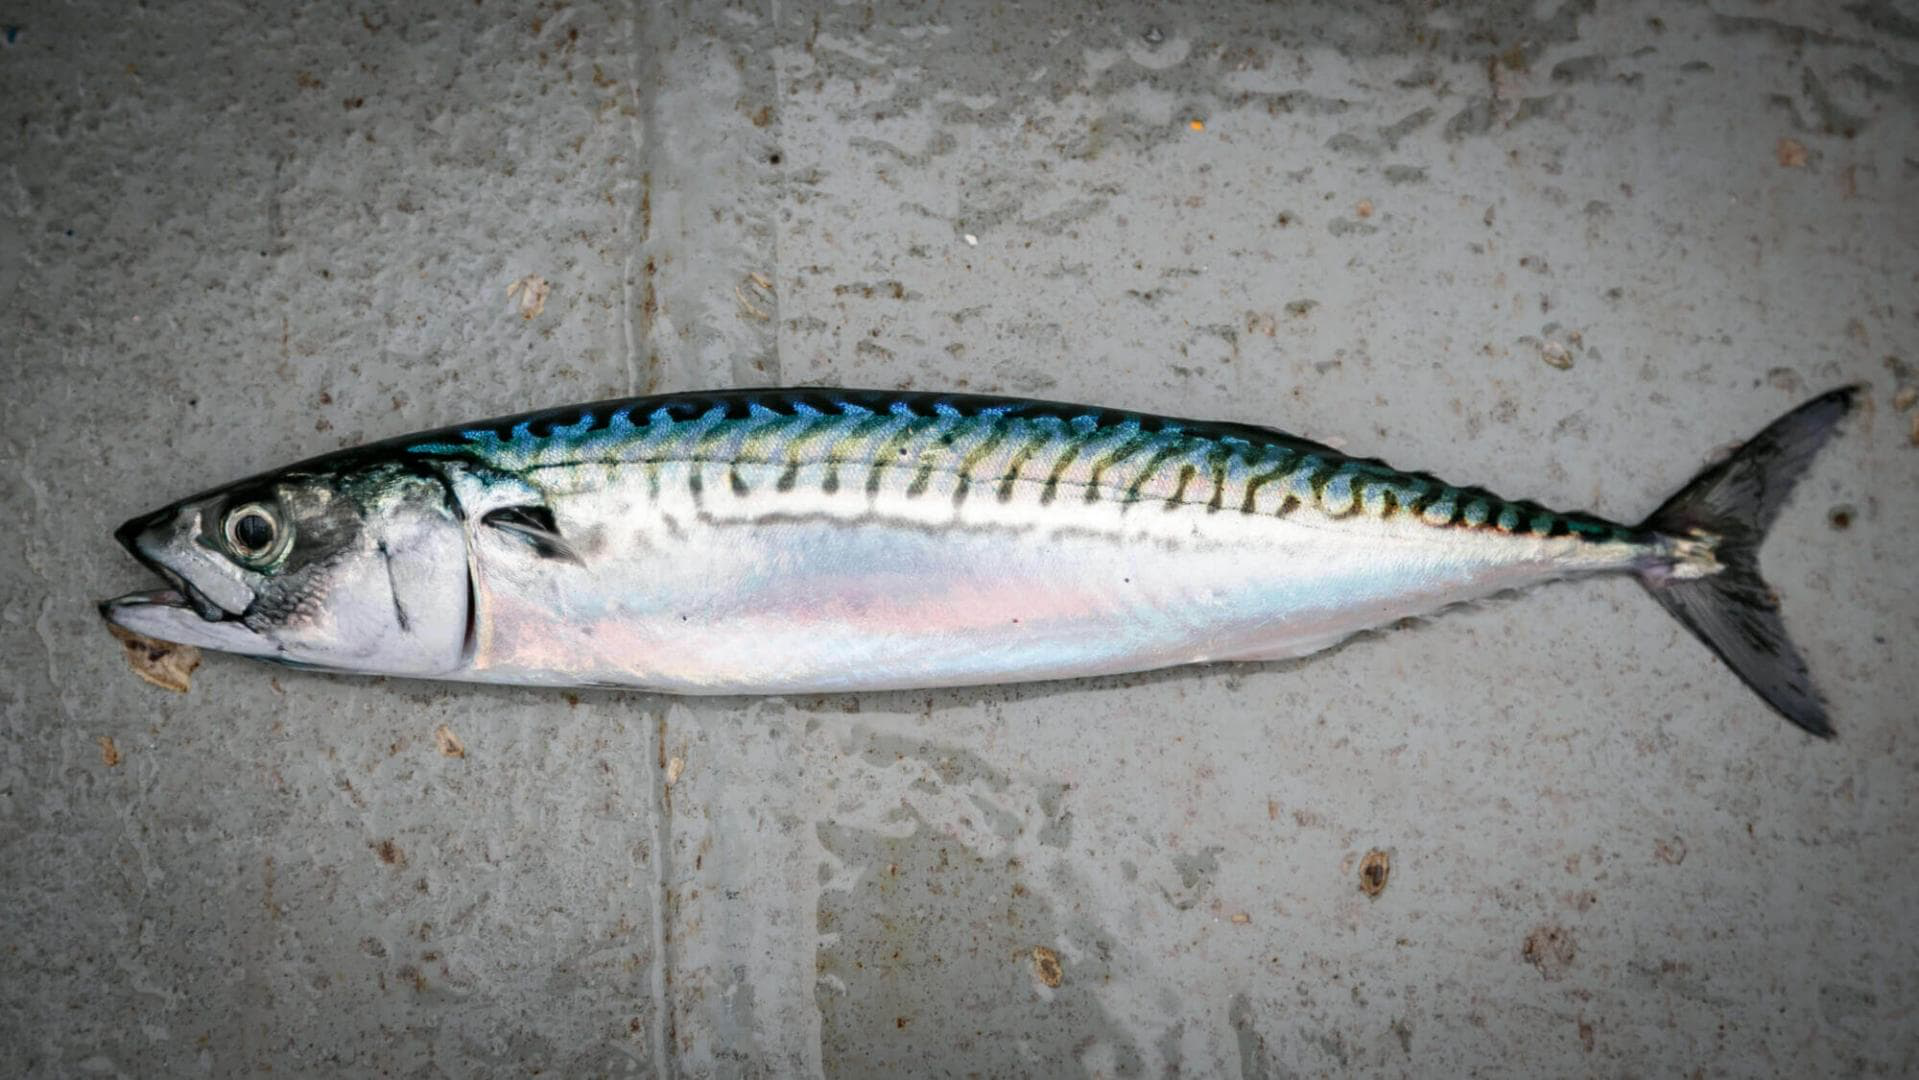

Species: Trout
Confidence: 82.51%


In [12]:
from IPython.display import display as ipy_display

content = upload.value[0]['content']
img_path = "../data/external/uploaded_fish.png"
with open(img_path, 'wb') as f:
    f.write(content)

img = Image.open(img_path)
ipy_display(img)

result = predict(img_path)
print(f"Species: {result['species']}")
print(f"Confidence: {result['confidence']}%")